In [1]:
from __future__ import annotations

import os
import json
import random
import hashlib
import platform
import subprocess
from pathlib import Path
from contextlib import contextmanager
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import torch
import mlflow
import mlflow.pytorch

import captum
from captum.attr import IntegratedGradients


# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Deterministic forward behaviour where supported.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Captum:", captum.__version__)
print("CUDA:", torch.version.cuda)
print("cuDNN:", torch.backends.cudnn.version())


# ---------------------------------------------------------
# Backend used for LSTM gradient / attribution computation
# ---------------------------------------------------------

@contextmanager
def attribution_backend():
    """
    Use a backend that supports differentiation through an
    evaluation-mode LSTM.

    CUDA:
        Disable cuDNN because cuDNN evaluation-mode RNN backward
        is unavailable.

    CPU:
        Disable MKLDNN for a controlled fallback implementation.
    """

    if DEVICE.type == "cuda":

        with torch.backends.cudnn.flags(enabled=False):
            yield

    else:

        with torch.backends.mkldnn.flags(enabled=False):
            yield

Device: cuda
PyTorch: 2.12.0+cu126
Captum: 0.9.0
CUDA: 12.6
cuDNN: 91002


In [2]:
def find_project_root(start: Path | None = None) -> Path:

    current = (
        Path.cwd().resolve()
        if start is None
        else Path(start).resolve()
    )

    candidates = [
        current,
        *current.parents
    ]

    for candidate in candidates:

        config_path = (
            candidate /
            "config" /
            "config.yaml"
        )

        if config_path.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root containing "
        "config/config.yaml"
    )


PROJECT_ROOT = find_project_root()

CONFIG_PATH = (
    PROJECT_ROOT /
    "config" /
    "config.yaml"
)

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)


LOOK_BACK = int(
    config["data"]["look_back"]
)

N_FEATURES = int(
    config["data"]["features"]
)

HORIZON = int(
    config["data"]["horizon"]
)

TARGET_COL = int(
    config["data"]["target_col"]
)

BATCH_SIZE = int(
    config["training"]["batch_size"]
)


RESEARCH_OUTPUT_DIR = (
    PROJECT_ROOT /
    "research_outputs" /
    "explainability_reliability"
)

RESEARCH_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", PROJECT_ROOT)
print("Config       :", CONFIG_PATH)

print("\nExperiment dimensions")
print("Lookback     :", LOOK_BACK)
print("Features     :", N_FEATURES)
print("Horizon      :", HORIZON)
print("Target col   :", TARGET_COL)
print("Batch size   :", BATCH_SIZE)

print(
    "\nResearch outputs:",
    RESEARCH_OUTPUT_DIR
)

Project root : /workspace
Config       : /workspace/config/config.yaml

Experiment dimensions
Lookback     : 120
Features     : 13
Horizon      : 30
Target col   : 0
Batch size   : 32

Research outputs: /workspace/research_outputs/explainability_reliability


In [4]:
# =========================================================
# IMPORTANT:
# Pin exact MLflow runs.
# Do not automatically select "latest".
# =========================================================

TRAINING_RUN_ID = "1ca274fa53f540b78c0796e36790d02b"

PREPROCESSING_RUN_ID = "95bec2ea578f4705933fd5a4e0fc422f"


MLFLOW_TRACKING_URI = os.getenv(
    "MLFLOW_TRACKING_URI",
    "http://localhost:5000"
)

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)


if "PASTE_" in TRAINING_RUN_ID:
    raise RuntimeError(
        "Set TRAINING_RUN_ID before continuing."
    )

if "PASTE_" in PREPROCESSING_RUN_ID:
    raise RuntimeError(
        "Set PREPROCESSING_RUN_ID before continuing."
    )


training_run = mlflow.get_run(
    TRAINING_RUN_ID
)

preprocessing_run = mlflow.get_run(
    PREPROCESSING_RUN_ID
)


print("Tracking URI:")
print(MLFLOW_TRACKING_URI)

print("\nTraining run:")
print(TRAINING_RUN_ID)
print(
    training_run.info.run_name
)

print("\nPreprocessing run:")
print(PREPROCESSING_RUN_ID)
print(
    preprocessing_run.info.run_name
)

Tracking URI:
http://localhost:5000

Training run:
1ca274fa53f540b78c0796e36790d02b
Hurber_loss_v.1

Preprocessing run:
95bec2ea578f4705933fd5a4e0fc422f
burly-midge-164


In [5]:
MODEL_ARTIFACT_PATH = "model"

ARTIFACT_PATHS = {

    "train_X":
        "data/train_X.pkl",

    "train_y":
        "data/train_y.pkl",

    "val_X":
        "data/val_X.pkl",

    "val_y":
        "data/val_y.pkl",
}


def load_pickle_artifact(
    run_id: str,
    artifact_path: str
):

    local_path = (
        mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=artifact_path
        )
    )

    return pd.read_pickle(
        local_path
    )


# ---------------------------------------------------------
# Model
# ---------------------------------------------------------

model_uri = (
    f"runs:/{TRAINING_RUN_ID}/"
    f"{MODEL_ARTIFACT_PATH}"
)

model = mlflow.pytorch.load_model(
    model_uri
)

model = model.to(DEVICE)

model.eval()


# ---------------------------------------------------------
# Data
# ---------------------------------------------------------

train_X = load_pickle_artifact(
    PREPROCESSING_RUN_ID,
    ARTIFACT_PATHS["train_X"]
)

train_y = load_pickle_artifact(
    PREPROCESSING_RUN_ID,
    ARTIFACT_PATHS["train_y"]
)

val_X = load_pickle_artifact(
    PREPROCESSING_RUN_ID,
    ARTIFACT_PATHS["val_X"]
)

val_y = load_pickle_artifact(
    PREPROCESSING_RUN_ID,
    ARTIFACT_PATHS["val_y"]
)


train_X = np.asarray(
    train_X,
    dtype=np.float32
)

train_y = np.asarray(
    train_y,
    dtype=np.float32
)

val_X = np.asarray(
    val_X,
    dtype=np.float32
)

val_y = np.asarray(
    val_y,
    dtype=np.float32
)


print(model)

print("\nShapes")
print("train_X:", train_X.shape)
print("train_y:", train_y.shape)
print("val_X  :", val_X.shape)
print("val_y  :", val_y.shape)


assert train_X.shape[1] == N_FEATURES
assert val_X.shape[1] == N_FEATURES

print("\nPASS: loaded data matches configured feature count.")

ForecastModel(
  (lstm): LSTM(13, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=30, bias=True)
)

Shapes
train_X: (1434496, 13)
train_y: (1434496, 1)
val_X  : (204928, 13)
val_y  : (204928, 1)

PASS: loaded data matches configured feature count.


In [6]:
# Number of legal forecasting windows
n_train_windows = (
    len(train_X)
    - LOOK_BACK
    - HORIZON
    + 1
)

assert n_train_windows > 0


# ---------------------------------------------------------
# Prefix sum allows us to calculate the mean value at
# each relative historical timestep efficiently.
#
# mean_window[j] =
# mean(train_X[j : j + n_train_windows])
# ---------------------------------------------------------

train_X_64 = train_X.astype(
    np.float64,
    copy=False
)

prefix = np.vstack([
    np.zeros(
        (1, N_FEATURES),
        dtype=np.float64
    ),
    np.cumsum(
        train_X_64,
        axis=0
    )
])


mean_window_np = np.empty(
    (LOOK_BACK, N_FEATURES),
    dtype=np.float64
)


for j in range(LOOK_BACK):

    window_sum = (
        prefix[j + n_train_windows]
        -
        prefix[j]
    )

    mean_window_np[j] = (
        window_sum /
        n_train_windows
    )


mean_window = torch.tensor(
    mean_window_np,
    dtype=torch.float32,
    device=DEVICE
)

baseline_ref = (
    mean_window
    .unsqueeze(0)
)


print(
    "Number training windows:",
    n_train_windows
)

print(
    "Baseline shape:",
    baseline_ref.shape
)

print(
    "Baseline sum:",
    baseline_ref.sum().item()
)

print(
    "Baseline norm:",
    baseline_ref.norm().item()
)


assert baseline_ref.shape == (
    1,
    LOOK_BACK,
    N_FEATURES
)

print(
    "\nPASS: historical mean-window baseline created."
)

Number training windows: 1434347
Baseline shape: torch.Size([1, 120, 13])
Baseline sum: 638.3571166992188
Baseline norm: 17.885820388793945

PASS: historical mean-window baseline created.


In [7]:
n_val_windows = (
    len(val_X)
    - LOOK_BACK
    - HORIZON
    + 1
)

assert n_val_windows > 0


# ---------------------------------------------------------
# Historical reconstruction:
# first sample from the final validation batch.
#
# This reproduces the semantics of:
#
# for X, y in val_dataloader:
#     val_x = X
#
# x = val_x[0:1]
#
# assuming shuffle=False.
# ---------------------------------------------------------

CANONICAL_WINDOW_START = (
    (n_val_windows - 1)
    // BATCH_SIZE
    * BATCH_SIZE
)


x_ref_np = val_X[
    CANONICAL_WINDOW_START:
    CANONICAL_WINDOW_START + LOOK_BACK
]


target_start = (
    CANONICAL_WINDOW_START
    + LOOK_BACK
)

target_end = (
    target_start
    + HORIZON
)

y_ref_np = val_y[
    target_start:
    target_end
]


x_ref = torch.tensor(
    x_ref_np,
    dtype=torch.float32,
    device=DEVICE
).unsqueeze(0)


def tensor_fingerprint(
    tensor: torch.Tensor
) -> str:

    array = (
        tensor
        .detach()
        .cpu()
        .contiguous()
        .numpy()
    )

    return hashlib.sha256(
        array.tobytes()
    ).hexdigest()


x_hash = tensor_fingerprint(
    x_ref
)

baseline_hash = tensor_fingerprint(
    baseline_ref
)


print(
    "Number validation windows:",
    n_val_windows
)

print(
    "Canonical window start:",
    CANONICAL_WINDOW_START
)

print(
    "\nx shape:",
    x_ref.shape
)

print(
    "target shape:",
    y_ref_np.shape
)

print(
    "\nx sum:",
    x_ref.sum().item()
)

print(
    "x norm:",
    x_ref.norm().item()
)

print(
    "\nx SHA256:",
    x_hash
)

print(
    "baseline SHA256:",
    baseline_hash
)


assert x_ref.shape == (
    1,
    LOOK_BACK,
    N_FEATURES
)

assert baseline_ref.shape == x_ref.shape

print(
    "\nPASS: canonical sample frozen."
)

Number validation windows: 204779
Canonical window start: 204768

x shape: torch.Size([1, 120, 13])
target shape: (30, 1)

x sum: 982.9219970703125
x norm: 29.780118942260742

x SHA256: 38b4cf0cbdd968b64fac9c8a70d411c403b0aa4df24fca1c2c0874a3c4e4cf2c
baseline SHA256: 791a4cbffafd166691c9b7df004491575ca9eb7beaed20ed1b214aee08353f63

PASS: canonical sample frozen.


In [12]:
model.eval()


# ---------------------------------------------------------
# 1. Evaluation mode
# ---------------------------------------------------------

modules_in_train_mode = [
    name
    for name, module
    in model.named_modules()
    if module.training
]


# ---------------------------------------------------------
# 2. Forward implementation equivalence
# ---------------------------------------------------------

with torch.no_grad():

    y_forward = model(
        x_ref
    )

    lstm_output, (h, c) = (
        model.lstm(
            x_ref
        )
    )

    last_hidden = (
        lstm_output[:, -1, :]
    )

    y_manual = (
        model.fc(
            last_hidden
        )
    )

    y_manual = (
        y_manual.reshape_as(
            y_forward
        )
    )


forward_max_difference = (
    y_forward
    .sub(y_manual)
    .abs()
    .max()
    .item()
)


# ---------------------------------------------------------
# 3. Repeated inference
# ---------------------------------------------------------

with torch.no_grad():

    repeated_predictions = [
        model(x_ref)
        .detach()
        .clone()

        for _ in range(10)
    ]


repeat_max_difference = max(

    (
        prediction
        -
        repeated_predictions[0]
    )
    .abs()
    .max()
    .item()

    for prediction
    in repeated_predictions[1:]
)


# ---------------------------------------------------------
# 4. Default backend vs attribution backend
# ---------------------------------------------------------

with torch.no_grad():

    y_default_backend = (
        model(x_ref)
        .detach()
        .clone()
    )


with attribution_backend():

    with torch.no_grad():

        y_attribution_backend = (
            model(x_ref)
            .detach()
            .clone()
        )


backend_max_difference = (
    y_default_backend
    -
    y_attribution_backend
).abs().max().item()


backend_allclose = torch.allclose(
    y_default_backend,
    y_attribution_backend,
    atol=1e-5,
    rtol=1e-5
)


# ---------------------------------------------------------
# Audit table
# ---------------------------------------------------------

audit_rows = [

    {
        "test":
            "model_eval_mode",

        "pass":
            model.training is False
    },

    {
        "test":
            "all_submodules_eval",

        "pass":
            len(modules_in_train_mode) == 0
    },

    {
        "test":
            "forward_manual_equivalence",

        "pass":
            forward_max_difference < 1e-6
    },

    {
        "test":
            "deterministic_forward",

        "pass":
            repeat_max_difference < 1e-6
    },

    {
        "test":
            "backend_forward_equivalence",

        "pass":
            bool(backend_allclose)
    }
]


audit_df = pd.DataFrame(
    audit_rows
)


display(audit_df)


print(
    "\nForward/manual max difference:",
    forward_max_difference
)

print(
    "Repeated-forward max difference:",
    repeat_max_difference
)

print(
    "Backend max difference:",
    backend_max_difference
)


# =========================================================
# Diagnostic report
# =========================================================

display(audit_df)

failed_tests = audit_df.loc[
    ~audit_df["pass"]
].copy()

print("\n=== FAILED INTEGRITY TESTS ===")

if len(failed_tests) == 0:
    print("None")
else:
    display(failed_tests)


print("\n=== DEFAULT BACKEND OUTPUT ===")
print(y_default_backend)


print("\n=== ATTRIBUTION BACKEND OUTPUT ===")
print(y_attribution_backend)


backend_difference = (
    y_default_backend
    -
    y_attribution_backend
).abs()


print("\n=== BACKEND DIFFERENCE ===")

print(
    "max absolute difference:",
    backend_difference.max().item()
)

print(
    "mean absolute difference:",
    backend_difference.mean().item()
)

print(
    "first-output difference:",
    backend_difference[0, 0].item()
)

print(
    "allclose:",
    torch.allclose(
        y_default_backend,
        y_attribution_backend,
        atol=1e-5,
        rtol=1e-5
    )
)


# =========================================================
# Separate structural/model integrity from backend
# numerical reproducibility.
# =========================================================

CORE_INTEGRITY_TESTS = [
    "model_eval_mode",
    "all_submodules_eval",
    "forward_manual_equivalence",
    "deterministic_forward",
]

BACKEND_TESTS = [
    "backend_forward_equivalence"
]


core_audit = audit_df[
    audit_df["test"].isin(
        CORE_INTEGRITY_TESTS
    )
].copy()


backend_audit = audit_df[
    audit_df["test"].isin(
        BACKEND_TESTS
    )
].copy()


core_integrity_pass = bool(
    core_audit["pass"].all()
)

backend_reproducibility_pass = bool(
    backend_audit["pass"].all()
)


print("=== CORE MODEL INTEGRITY ===")

display(core_audit)

print(
    "Core integrity:",
    "PASS"
    if core_integrity_pass
    else "FAIL"
)


print(
    "\n=== BACKEND NUMERICAL REPRODUCIBILITY ==="
)

display(backend_audit)

print(
    "Backend reproducibility:",
    "PASS"
    if backend_reproducibility_pass
    else "WARN"
)


if not backend_reproducibility_pass:

    print(
        "\nWARNING:"
        "\nThe same frozen model and input produce"
        "\nmaterially different forward values when"
        "\nswitching between cuDNN and fallback LSTM"
        "\nimplementations."
    )

,test,pass
0,model_eval_mode,True
1,all_submodules_eval,True
2,forward_manual_equivalence,True
3,deterministic_forward,True
4,backend_forward_equivalence,False



Forward/manual max difference: 0.0
Repeated-forward max difference: 0.0
Backend max difference: 0.07050357758998871


,test,pass
0,model_eval_mode,True
1,all_submodules_eval,True
2,forward_manual_equivalence,True
3,deterministic_forward,True
4,backend_forward_equivalence,False



=== FAILED INTEGRITY TESTS ===


,test,pass
4,backend_forward_equivalence,False



=== DEFAULT BACKEND OUTPUT ===
tensor([[0.0375, 0.0454, 0.0509, 0.0563, 0.0588, 0.0606, 0.0653, 0.0672, 0.0713,
         0.0751, 0.0765, 0.0782, 0.0794, 0.0820, 0.0822, 0.0822, 0.0807, 0.0816,
         0.0844, 0.0884, 0.0912, 0.0919, 0.0931, 0.0953, 0.0983, 0.1012, 0.1031,
         0.1049, 0.1066, 0.1076]], device='cuda:0')

=== ATTRIBUTION BACKEND OUTPUT ===
tensor([[0.1010, 0.1071, 0.1155, 0.1221, 0.1250, 0.1282, 0.1319, 0.1344, 0.1380,
         0.1410, 0.1448, 0.1459, 0.1453, 0.1477, 0.1517, 0.1521, 0.1512, 0.1513,
         0.1509, 0.1518, 0.1550, 0.1557, 0.1569, 0.1605, 0.1617, 0.1628, 0.1657,
         0.1645, 0.1661, 0.1669]], device='cuda:0')

=== BACKEND DIFFERENCE ===
max absolute difference: 0.07050357758998871
mean absolute difference: 0.06518825888633728
first-output difference: 0.06354876607656479
allclose: False

Do not treat attribution results as canonical until these failures are explained.

PASS: model integrity audit completed.


In [15]:
from contextlib import nullcontext


def run_forward_condition(
    model,
    x,
    baseline,
    mode,
    cudnn_enabled
):

    if mode == "train":
        model.train()

    elif mode == "eval":
        model.eval()

    else:
        raise ValueError(
            f"Unknown mode: {mode}"
        )


    if DEVICE.type == "cuda":

        backend_context = (
            torch.backends.cudnn.flags(
                enabled=cudnn_enabled
            )
        )

    else:

        backend_context = nullcontext()


    with backend_context:

        with torch.no_grad():

            fx = (
                model(x)
                .detach()
                .clone()
            )

            fb = (
                model(baseline)
                .detach()
                .clone()
            )


    return fx, fb


conditions = [
    ("eval_cudnn", "eval", True),
    ("train_cudnn", "train", True),
    ("eval_fallback", "eval", False),
    ("train_fallback", "train", False),
]


forward_outputs = {}
forward_rows = []


for name, mode, cudnn_enabled in conditions:

    fx_condition, fb_condition = (
        run_forward_condition(
            model=model,
            x=x_ref,
            baseline=baseline_ref,
            mode=mode,
            cudnn_enabled=cudnn_enabled
        )
    )


    forward_outputs[name] = {
        "x": fx_condition,
        "baseline": fb_condition
    }


    forward_rows.append({

        "condition":
            name,

        "mode":
            mode,

        "cudnn_enabled":
            cudnn_enabled,

        "F_x_h1":
            fx_condition[0, 0].item(),

        "F_baseline_h1":
            fb_condition[0, 0].item(),

        "difference_h1":
            (
                fx_condition[0, 0]
                -
                fb_condition[0, 0]
            ).item()
    })


# Restore research default
model.eval()


forward_condition_df = pd.DataFrame(
    forward_rows
)

display(forward_condition_df)
comparison_pairs = [

    (
        "eval_cudnn",
        "train_cudnn"
    ),

    (
        "eval_cudnn",
        "eval_fallback"
    ),

    (
        "train_cudnn",
        "train_fallback"
    ),

    (
        "eval_fallback",
        "train_fallback"
    )
]


comparison_rows = []


for a, b in comparison_pairs:

    ya = forward_outputs[a]["x"]
    yb = forward_outputs[b]["x"]

    difference = (
        ya - yb
    ).abs()


    comparison_rows.append({

        "condition_A":
            a,

        "condition_B":
            b,

        "max_abs_difference":
            difference.max().item(),

        "mean_abs_difference":
            difference.mean().item(),

        "horizon_1_difference":
            difference[0, 0].item(),

        "allclose_1e-5":
            bool(
                torch.allclose(
                    ya,
                    yb,
                    atol=1e-5,
                    rtol=1e-5
                )
            )
    })


forward_comparison_df = pd.DataFrame(
    comparison_rows
)

print("\n=== PAIRWISE FORWARD COMPARISON ===")

display(
    forward_comparison_df
)
print("\n=== LSTM CONFIGURATION ===")

print(
    "num_layers:",
    model.lstm.num_layers
)

print(
    "LSTM dropout:",
    model.lstm.dropout
)

print(
    "bidirectional:",
    model.lstm.bidirectional
)


dropout_modules = [

    (name, module)

    for name, module
    in model.named_modules()

    if isinstance(
        module,
        torch.nn.Dropout
    )
]


print(
    "Explicit Dropout modules:",
    dropout_modules
)

,condition,mode,cudnn_enabled,F_x_h1,F_baseline_h1,difference_h1
0,eval_cudnn,eval,True,0.037474,0.147329,-0.109855
1,train_cudnn,train,True,0.037474,0.147329,-0.109855
2,eval_fallback,eval,False,0.101023,0.205897,-0.104874
3,train_fallback,train,False,0.101023,0.205897,-0.104874



=== PAIRWISE FORWARD COMPARISON ===


,condition_A,condition_B,max_abs_difference,mean_abs_difference,horizon_1_difference,allclose_1e-5
0,eval_cudnn,train_cudnn,0.000000,0.000000,0.000000,True
1,eval_cudnn,eval_fallback,0.070504,0.065188,0.063549,False
2,train_cudnn,train_fallback,0.070504,0.065188,0.063549,False
3,eval_fallback,train_fallback,0.000000,0.000000,0.000000,True



=== LSTM CONFIGURATION ===
num_layers: 1
LSTM dropout: 0.0
bidirectional: False
Explicit Dropout modules: []


In [17]:
def run_gradient_condition(
    model,
    x,
    mode,
    cudnn_enabled,
    target_index=0
):

    if mode == "train":
        model.train()

    elif mode == "eval":
        model.eval()

    else:
        raise ValueError(mode)


    if DEVICE.type == "cuda":

        backend_context = (
            torch.backends.cudnn.flags(
                enabled=cudnn_enabled
            )
        )

    else:

        backend_context = nullcontext()


    x_work = (
        x.detach()
         .clone()
         .requires_grad_(True)
    )


    try:

        with backend_context:

            output = (
                model(x_work)[
                    0,
                    target_index
                ]
            )

            gradient = (
                torch.autograd.grad(
                    outputs=output,
                    inputs=x_work,
                    create_graph=False,
                    retain_graph=False
                )[0]
            )


        return {
            "success":
                True,

            "output":
                output.detach(),

            "gradient":
                gradient.detach(),

            "error":
                None
        }


    except RuntimeError as exc:

        return {
            "success":
                False,

            "output":
                None,

            "gradient":
                None,

            "error":
                str(exc)
        }
gradient_results = {}

gradient_rows = []


for name, mode, cudnn_enabled in conditions:

    result = run_gradient_condition(

        model=model,

        x=x_ref,

        mode=mode,

        cudnn_enabled=cudnn_enabled,

        target_index=0
    )


    gradient_results[name] = result


    if result["success"]:

        g = result["gradient"]


        timestep_norms = (
            g[0]
            .norm(
                p=2,
                dim=1
            )
        )


        gradient_rows.append({

            "condition":
                name,

            "success":
                True,

            "F_x":
                result["output"].item(),

            "gradient_max_abs":
                g.abs().max().item(),

            "gradient_l2":
                g.norm().item(),

            "gradient_mean_abs":
                g.abs().mean().item(),

            "min_timestep_norm":
                timestep_norms.min().item(),

            "max_timestep_norm":
                timestep_norms.max().item(),

            "temporal_amplification_ratio":
                (
                    timestep_norms.max()
                    /
                    (
                        timestep_norms.min()
                        + 1e-30
                    )
                ).item(),

            "error":
                None
        })


    else:

        gradient_rows.append({

            "condition":
                name,

            "success":
                False,

            "F_x":
                np.nan,

            "gradient_max_abs":
                np.nan,

            "gradient_l2":
                np.nan,

            "gradient_mean_abs":
                np.nan,

            "min_timestep_norm":
                np.nan,

            "max_timestep_norm":
                np.nan,

            "temporal_amplification_ratio":
                np.nan,

            "error":
                result["error"]
        })


# Restore research default
model.eval()


gradient_condition_df = pd.DataFrame(
    gradient_rows
)


display(
    gradient_condition_df
)

,condition,success,F_x,gradient_max_abs,gradient_l2,gradient_mean_abs,min_timestep_norm,max_timestep_norm,temporal_amplification_ratio,error
0,eval_cudnn,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cudnn RNN backward can only be called in train...
1,train_cudnn,True,0.037474,2.306358e+12,2.895122e+12,8.974320e+09,0.218367,2.674034e+12,1.224558e+13,None
2,eval_fallback,True,0.101023,1.950355e+14,2.448306e+14,7.627304e+11,0.075225,2.260646e+14,3.005186e+15,None
3,train_fallback,True,0.101023,1.950355e+14,2.448306e+14,7.627304e+11,0.075225,2.260646e+14,3.005186e+15,None


In [18]:
historical_grad = (
    gradient_results[
        "train_cudnn"
    ]["gradient"]
)

fallback_grad = (
    gradient_results[
        "eval_fallback"
    ]["gradient"]
)


if (
    historical_grad is not None
    and
    fallback_grad is not None
):

    historical_flat = (
        historical_grad
        .flatten()
        .unsqueeze(0)
    )

    fallback_flat = (
        fallback_grad
        .flatten()
        .unsqueeze(0)
    )


    cosine_similarity = (
        torch.nn.functional
        .cosine_similarity(
            historical_flat,
            fallback_flat
        )
        .item()
    )


    max_abs_difference = (
        historical_grad
        -
        fallback_grad
    ).abs().max().item()


    relative_l2_difference = (

        (
            historical_grad
            -
            fallback_grad
        ).norm()

        /

        (
            historical_grad.norm()
            + 1e-30
        )

    ).item()


    print(
        "Cosine similarity:",
        cosine_similarity
    )

    print(
        "Max absolute gradient difference:",
        max_abs_difference
    )

    print(
        "Relative L2 gradient difference:",
        relative_l2_difference
    )

Cosine similarity: 0.9999544024467468
Max absolute gradient difference: 192729107660800.0
Relative L2 gradient difference: 83.5666275024414


In [19]:
def manual_lstm_forward(
    model,
    x,
    dtype=torch.float64,
    device="cpu"
):
    """
    Explicit single-layer, unidirectional LSTM recurrence.

    Reconstructs:

        LSTM(13 -> 64)
        final hidden output
        Linear(64 -> 30)

    from the frozen saved parameters.
    """

    assert model.lstm.num_layers == 1
    assert not model.lstm.bidirectional


    # -----------------------------------------------------
    # Copy input
    # -----------------------------------------------------

    x_work = (
        x.detach()
         .to(
             device=device,
             dtype=dtype
         )
    )


    # -----------------------------------------------------
    # LSTM parameters
    # -----------------------------------------------------

    W_ih = (
        model.lstm.weight_ih_l0
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )

    W_hh = (
        model.lstm.weight_hh_l0
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )

    b_ih = (
        model.lstm.bias_ih_l0
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )

    b_hh = (
        model.lstm.bias_hh_l0
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )


    # -----------------------------------------------------
    # FC parameters
    # -----------------------------------------------------

    W_fc = (
        model.fc.weight
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )

    b_fc = (
        model.fc.bias
        .detach()
        .to(
            device=device,
            dtype=dtype
        )
    )


    batch_size = x_work.shape[0]

    hidden_size = (
        model.lstm.hidden_size
    )


    h_t = torch.zeros(
        batch_size,
        hidden_size,
        dtype=dtype,
        device=device
    )

    c_t = torch.zeros_like(
        h_t
    )


    hidden_sequence = []
    cell_sequence = []


    # =====================================================
    # Explicit recurrence
    # =====================================================

    for t in range(
        x_work.shape[1]
    ):

        x_t = x_work[:, t, :]


        gates = (
            x_t @ W_ih.T
            +
            b_ih
            +
            h_t @ W_hh.T
            +
            b_hh
        )


        i_t, f_t, g_t, o_t = (
            gates.chunk(
                4,
                dim=1
            )
        )


        i_t = torch.sigmoid(i_t)
        f_t = torch.sigmoid(f_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)


        c_t = (
            f_t * c_t
            +
            i_t * g_t
        )


        h_t = (
            o_t
            *
            torch.tanh(c_t)
        )


        hidden_sequence.append(
            h_t.clone()
        )

        cell_sequence.append(
            c_t.clone()
        )


    hidden_sequence = torch.stack(
        hidden_sequence,
        dim=1
    )

    cell_sequence = torch.stack(
        cell_sequence,
        dim=1
    )


    prediction = (
        h_t @ W_fc.T
        +
        b_fc
    )


    return {
        "prediction":
            prediction,

        "hidden_sequence":
            hidden_sequence,

        "cell_sequence":
            cell_sequence,

        "final_hidden":
            h_t,

        "final_cell":
            c_t,
    }

In [21]:
manual32 = manual_lstm_forward(
    model=model,
    x=x_ref,
    dtype=torch.float32,
    device="cpu"
)


manual64 = manual_lstm_forward(
    model=model,
    x=x_ref,
    dtype=torch.float64,
    device="cpu"
)


y_manual32 = (
    manual32["prediction"]
    .detach()
    .cpu()
)


y_manual64 = (
    manual64["prediction"]
    .detach()
    .cpu()
)


y_cudnn = (
    forward_outputs[
        "eval_cudnn"
    ]["x"]
    .detach()
    .cpu()
)


y_fallback = (
    forward_outputs[
        "eval_fallback"
    ]["x"]
    .detach()
    .cpu()
)


print(
    "=== HORIZON 1 ==="
)

print(
    "cuDNN float32   :",
    y_cudnn[0, 0].item()
)

print(
    "fallback float32:",
    y_fallback[0, 0].item()
)

print(
    "manual float32  :",
    y_manual32[0, 0].item()
)

print(
    "manual float64  :",
    y_manual64[0, 0].item()
)
reference64 = (
    y_manual64.float()
)


reference_rows = []


predictions_to_compare = {

    "cudnn_float32":
        y_cudnn,

    "fallback_float32":
        y_fallback,

    "manual_float32":
        y_manual32,
}


for name, prediction in (
    predictions_to_compare.items()
):

    diff = (
        prediction
        -
        reference64
    ).abs()


    reference_rows.append({

        "implementation":
            name,

        "F_x_h1":
            prediction[
                0,
                0
            ].item(),

        "max_abs_difference_vs_manual64":
            diff.max().item(),

        "mean_abs_difference_vs_manual64":
            diff.mean().item(),

        "horizon1_difference_vs_manual64":
            diff[
                0,
                0
            ].item()
    })


reference_comparison_df = (
    pd.DataFrame(
        reference_rows
    )
)


print(
    "\n=== COMPARISON WITH MANUAL FLOAT64 ==="
)

display(
    reference_comparison_df
)

=== HORIZON 1 ===
cuDNN float32   : 0.03747373819351196
fallback float32: 0.10102250427007675
manual float32  : 0.11460498720407486
manual float64  : 0.07259457639824977

=== COMPARISON WITH MANUAL FLOAT64 ===


,implementation,F_x_h1,max_abs_difference_vs_manual64,mean_abs_difference_vs_manual64,horizon1_difference_vs_manual64
0,cudnn_float32,0.037474,0.051132,0.046321,0.035121
1,fallback_float32,0.101023,0.028428,0.018867,0.028428
2,manual_float32,0.114605,0.042010,0.018617,0.042010


In [23]:
def get_backend_lstm_sequence(
    model,
    x,
    cudnn_enabled
):

    model.eval()

    with torch.backends.cudnn.flags(
        enabled=cudnn_enabled
    ):

        with torch.no_grad():

            output, (h, c) = (
                model.lstm(x)
            )


    return (
        output.detach().cpu(),
        h.detach().cpu(),
        c.detach().cpu()
    )
sequence_cudnn, _, _ = (
    get_backend_lstm_sequence(
        model,
        x_ref,
        cudnn_enabled=True
    )
)


sequence_fallback, _, _ = (
    get_backend_lstm_sequence(
        model,
        x_ref,
        cudnn_enabled=False
    )
)


sequence_manual64 = (
    manual64[
        "hidden_sequence"
    ]
    .float()
    .cpu()
)


# ---------------------------------------------------------
# Backend-to-backend state difference
# ---------------------------------------------------------

state_difference = (
    sequence_cudnn
    -
    sequence_fallback
).norm(
    p=2,
    dim=2
)[0]


# ---------------------------------------------------------
# Difference against manual float64
# ---------------------------------------------------------

cudnn_vs_manual64 = (
    sequence_cudnn
    -
    sequence_manual64
).norm(
    p=2,
    dim=2
)[0]


fallback_vs_manual64 = (
    sequence_fallback
    -
    sequence_manual64
).norm(
    p=2,
    dim=2
)[0]


state_divergence_df = pd.DataFrame({

    "timestep":
        np.arange(
            LOOK_BACK
        ),

    "cudnn_vs_fallback":
        state_difference.numpy(),

    "cudnn_vs_manual64":
        cudnn_vs_manual64.numpy(),

    "fallback_vs_manual64":
        fallback_vs_manual64.numpy(),
})


display(
    state_divergence_df.iloc[
        [
            0,
            1,
            2,
            4,
            9,
            19,
            39,
            59,
            79,
            99,
            109,
            119,
        ]
    ]
)

,timestep,cudnn_vs_fallback,cudnn_vs_manual64,fallback_vs_manual64
0,0,0.000008,0.000008,1.153291e-07
1,1,0.000013,0.000013,3.865859e-07
2,2,0.000012,0.000012,3.564909e-07
4,4,0.000016,0.000016,3.474707e-07
9,9,0.000036,0.000036,8.098542e-07
19,19,0.005359,0.005127,2.320089e-04
39,39,2.401724,2.347286,2.219448e-01
59,59,0.979134,1.056719,4.174916e-01
79,79,1.121583,1.681906,1.355402e+00
99,99,0.922074,1.207693,1.102352e+00


In [24]:
def run_ig_condition(
    model,
    x,
    baseline,
    mode,
    cudnn_enabled,
    target_index=0,
    n_steps=50
):

    if mode == "train":
        model.train()

    elif mode == "eval":
        model.eval()

    else:
        raise ValueError(mode)


    if DEVICE.type == "cuda":

        backend_context = (
            torch.backends.cudnn.flags(
                enabled=cudnn_enabled
            )
        )

    else:

        backend_context = (
            attribution_backend()
        )


    with backend_context:

        with torch.no_grad():

            fx = (
                model(x)[
                    0,
                    target_index
                ]
            )

            fb = (
                model(baseline)[
                    0,
                    target_index
                ]
            )


        def target_forward(z):

            return model(z)[
                :,
                target_index
            ]


        ig = IntegratedGradients(
            target_forward
        )


        attribution, delta = (
            ig.attribute(
                x,
                baselines=baseline,
                n_steps=n_steps,
                return_convergence_delta=True
            )
        )


    output_difference = (
        fx - fb
    ).item()


    attribution_sum = (
        attribution.sum().item()
    )


    completeness_error = (
        attribution_sum
        -
        output_difference
    )


    normalized_error = (

        abs(
            completeness_error
        )

        /

        (
            abs(
                output_difference
            )
            +
            1e-12
        )
    )


    return {

        "mode":
            mode,

        "cudnn_enabled":
            cudnn_enabled,

        "n_steps":
            n_steps,

        "fx":
            fx.item(),

        "fb":
            fb.item(),

        "output_difference":
            output_difference,

        "ig_sum":
            attribution_sum,

        "captum_delta":
            delta.item(),

        "ig_max_abs":
            attribution
            .abs()
            .max()
            .item(),

        "normalized_completeness_error":
            normalized_error,

        "attribution":
            attribution.detach(),
    }

In [26]:
historical_cudnn_ig = (
    run_ig_condition(
        model=model,
        x=x_ref,
        baseline=baseline_ref,
        mode="train",
        cudnn_enabled=True,
        target_index=0,
        n_steps=50
    )
)


fallback_ig = (
    run_ig_condition(
        model=model,
        x=x_ref,
        baseline=baseline_ref,
        mode="eval",
        cudnn_enabled=False,
        target_index=0,
        n_steps=50
    )
)


# Always restore research default
model.eval()


ig_backend_df = pd.DataFrame([

    {
        k: v
        for k, v
        in historical_cudnn_ig.items()
        if k != "attribution"
    },

    {
        k: v
        for k, v
        in fallback_ig.items()
        if k != "attribution"
    }
])


display(
    ig_backend_df
)
ig_backend_df.to_csv(

    RESEARCH_OUTPUT_DIR /
    "ig_backend_comparison.csv",

    index=False
)

,mode,cudnn_enabled,n_steps,fx,fb,output_difference,ig_sum,captum_delta,ig_max_abs,normalized_completeness_error
0,train,True,50,0.037474,0.147329,-0.109855,-1.613458e+13,-1.613458e+13,4.101595e+13,1.468713e+14
1,eval,False,50,0.101023,0.205897,-0.104874,-1.738272e+14,-1.738272e+14,3.798810e+13,1.657479e+15


In [27]:
cudnn_gradient = (
    gradient_results[
        "train_cudnn"
    ]["gradient"]
)


fallback_gradient = (
    gradient_results[
        "eval_fallback"
    ]["gradient"]
)


gradient_cosine = (
    torch.nn.functional
    .cosine_similarity(
        cudnn_gradient
        .flatten()
        .unsqueeze(0),

        fallback_gradient
        .flatten()
        .unsqueeze(0)
    )
    .item()
)


gradient_norm_ratio = (

    fallback_gradient.norm()

    /

    cudnn_gradient.norm()

).item()


gradient_backend_summary = (
    pd.DataFrame([{

        "cudnn_gradient_l2":
            cudnn_gradient.norm().item(),

        "fallback_gradient_l2":
            fallback_gradient.norm().item(),

        "fallback_to_cudnn_norm_ratio":
            gradient_norm_ratio,

        "cosine_similarity":
            gradient_cosine,

        "relative_l2_difference":
            (
                (
                    fallback_gradient
                    -
                    cudnn_gradient
                ).norm()

                /

                cudnn_gradient.norm()
            ).item()
    }])
)


display(
    gradient_backend_summary
)


gradient_backend_summary.to_csv(

    RESEARCH_OUTPUT_DIR /
    "gradient_backend_comparison.csv",

    index=False
)

,cudnn_gradient_l2,fallback_gradient_l2,fallback_to_cudnn_norm_ratio,cosine_similarity,relative_l2_difference
0,2.895122e+12,2.448306e+14,84.566582,0.999954,83.566628


In [9]:
TARGET_INDEX = 0
IG_STEPS = 50


model.eval()


with attribution_backend():

    # =====================================================
    # Endpoint predictions
    # =====================================================

    with torch.no_grad():

        fx_before = model(
            x_ref
        )[0, TARGET_INDEX]

        fb = model(
            baseline_ref
        )[0, TARGET_INDEX]


    # =====================================================
    # Raw input gradient
    # =====================================================

    x_grad = (
        x_ref
        .detach()
        .clone()
        .requires_grad_(True)
    )


    fx_for_gradient = model(
        x_grad
    )[0, TARGET_INDEX]


    grad = torch.autograd.grad(
        outputs=fx_for_gradient,
        inputs=x_grad,
        create_graph=False,
        retain_graph=False
    )[0]


    # =====================================================
    # Integrated Gradients
    # =====================================================

    def forward_target(z):
        return model(z)[:, TARGET_INDEX]


    ig = IntegratedGradients(
        forward_target
    )


    attribution, delta = (
        ig.attribute(
            x_ref,
            baselines=baseline_ref,
            n_steps=IG_STEPS,
            return_convergence_delta=True
        )
    )


    # =====================================================
    # Endpoint after attribution
    # =====================================================

    with torch.no_grad():

        fx_after = model(
            x_ref
        )[0, TARGET_INDEX]


# =========================================================
# Consistency metrics
# =========================================================

endpoint_consistent = (

    torch.allclose(
        fx_before,
        fx_for_gradient.detach(),
        atol=1e-6,
        rtol=1e-6
    )

    and

    torch.allclose(
        fx_before,
        fx_after,
        atol=1e-6,
        rtol=1e-6
    )
)


true_difference = (
    fx_after - fb
).item()


attribution_sum = (
    attribution
    .sum()
    .item()
)


manual_completeness_error = (
    attribution_sum
    -
    true_difference
)


normalized_completeness_error = (

    abs(
        manual_completeness_error
    )

    /

    (
        abs(true_difference)
        + 1e-12
    )
)


# =========================================================
# Gradient metrics
# =========================================================

gradient_max_abs = (
    grad
    .abs()
    .max()
    .item()
)


gradient_l2 = (
    grad
    .norm()
    .item()
)


gradient_mean_abs = (
    grad
    .abs()
    .mean()
    .item()
)


gradient_finite = (
    torch.isfinite(grad)
    .all()
    .item()
)


grad_per_timestep = (
    grad[0]
    .norm(
        p=2,
        dim=1
    )
)


# =========================================================
# Print canonical result
# =========================================================

print("=== FORWARD CONSISTENCY ===")

print(
    "F(x) before :",
    fx_before.item()
)

print(
    "F(x) grad   :",
    fx_for_gradient.item()
)

print(
    "F(x) after  :",
    fx_after.item()
)

print(
    "consistent  :",
    endpoint_consistent
)


print("\n=== ENDPOINTS ===")

print(
    "F(x)        :",
    fx_after.item()
)

print(
    "F(baseline) :",
    fb.item()
)

print(
    "difference  :",
    true_difference
)


print("\n=== INPUT GRADIENT ===")

print(
    "finite      :",
    gradient_finite
)

print(
    "max abs     :",
    gradient_max_abs
)

print(
    "L2 norm     :",
    gradient_l2
)

print(
    "mean abs    :",
    gradient_mean_abs
)


print("\n=== TEMPORAL GRADIENT ===")

print(
    "min timestep norm:",
    grad_per_timestep.min().item()
)

print(
    "max timestep norm:",
    grad_per_timestep.max().item()
)

print(
    "first 10:"
)

print(
    grad_per_timestep[:10]
)

print(
    "last 10:"
)

print(
    grad_per_timestep[-10:]
)


print("\n=== INTEGRATED GRADIENTS ===")

print(
    "n_steps:",
    IG_STEPS
)

print(
    "IG sum:",
    attribution_sum
)

print(
    "Captum delta:",
    delta.item()
)

print(
    "manual completeness error:",
    manual_completeness_error
)

print(
    "max |IG|:",
    attribution
    .abs()
    .max()
    .item()
)

print(
    "normalized completeness error:",
    normalized_completeness_error
)


assert endpoint_consistent

print(
    "\nPASS: controlled attribution case completed."
)

=== FORWARD CONSISTENCY ===
F(x) before : 0.10102250427007675
F(x) grad   : 0.10102250427007675
F(x) after  : 0.10102250427007675
consistent  : True

=== ENDPOINTS ===
F(x)        : 0.10102250427007675
F(baseline) : 0.20589694380760193
difference  : -0.10487443953752518

=== INPUT GRADIENT ===
finite      : True
max abs     : 195035471544320.0
L2 norm     : 244830600953856.0
mean abs    : 762730446848.0

=== TEMPORAL GRADIENT ===
min timestep norm: 0.07522482424974442
max timestep norm: 226064613769216.0
first 10:
tensor([2.2606e+14, 6.7467e+13, 1.3685e+13, 2.3538e+13, 1.7429e+13, 2.3317e+13,
        1.1151e+13, 2.0313e+13, 3.0433e+13, 3.3749e+13], device='cuda:0')
last 10:
tensor([0.7989, 0.4712, 0.7611, 0.3992, 0.5940, 0.3876, 0.2631, 0.1042, 0.0809,
        0.0752], device='cuda:0')

=== INTEGRATED GRADIENTS ===
n_steps: 50
IG sum: -173827225026560.0
Captum delta: -173827225026560.0
manual completeness error: -173827225026559.9
max |IG|: 37988104929280.0
normalized completeness erro

In [10]:
case_summary = {

    # -----------------------------------------------------
    # Identity
    # -----------------------------------------------------

    "training_run_id":
        TRAINING_RUN_ID,

    "preprocessing_run_id":
        PREPROCESSING_RUN_ID,

    "canonical_window_start":
        int(CANONICAL_WINDOW_START),

    "target_index":
        int(TARGET_INDEX),

    "x_sha256":
        x_hash,

    "baseline_sha256":
        baseline_hash,


    # -----------------------------------------------------
    # Model dimensions
    # -----------------------------------------------------

    "look_back":
        LOOK_BACK,

    "n_features":
        N_FEATURES,

    "horizon":
        HORIZON,


    # -----------------------------------------------------
    # Forward values
    # -----------------------------------------------------

    "fx":
        fx_after.item(),

    "f_baseline":
        fb.item(),

    "output_difference":
        true_difference,

    "endpoint_consistent":
        bool(endpoint_consistent),


    # -----------------------------------------------------
    # Input-gradient metrics
    # -----------------------------------------------------

    "gradient_finite":
        bool(gradient_finite),

    "gradient_max_abs":
        gradient_max_abs,

    "gradient_l2":
        gradient_l2,

    "gradient_mean_abs":
        gradient_mean_abs,


    # -----------------------------------------------------
    # Integrated Gradients
    # -----------------------------------------------------

    "ig_steps":
        IG_STEPS,

    "ig_sum":
        attribution_sum,

    "ig_max_abs":
        attribution
        .abs()
        .max()
        .item(),

    "captum_delta":
        delta.item(),

    "manual_completeness_error":
        manual_completeness_error,

    "normalized_completeness_error":
        normalized_completeness_error,


    # -----------------------------------------------------
    # Environment
    # -----------------------------------------------------

    "device":
        str(DEVICE),

    "torch_version":
        torch.__version__,

    "captum_version":
        captum.__version__,

    "cuda_version":
        torch.version.cuda,

    "cudnn_version":
        torch.backends.cudnn.version(),

    "seed":
        SEED,
}


# ---------------------------------------------------------
# Save JSON summary
# ---------------------------------------------------------

summary_path = (
    RESEARCH_OUTPUT_DIR /
    "canonical_failure_case.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        case_summary,
        f,
        indent=4
    )


# ---------------------------------------------------------
# Save raw tensors used in the experiment
# ---------------------------------------------------------

np.save(
    RESEARCH_OUTPUT_DIR /
    "canonical_input.npy",

    x_ref
    .detach()
    .cpu()
    .numpy()
)


np.save(
    RESEARCH_OUTPUT_DIR /
    "canonical_baseline.npy",

    baseline_ref
    .detach()
    .cpu()
    .numpy()
)


np.save(
    RESEARCH_OUTPUT_DIR /
    "canonical_input_gradient.npy",

    grad
    .detach()
    .cpu()
    .numpy()
)


np.save(
    RESEARCH_OUTPUT_DIR /
    "canonical_ig_attribution.npy",

    attribution
    .detach()
    .cpu()
    .numpy()
)


# ---------------------------------------------------------
# Save timestep gradient table
# ---------------------------------------------------------

timestep_gradient_df = pd.DataFrame({

    "historical_timestep":
        np.arange(LOOK_BACK),

    "gradient_l2":
        grad_per_timestep
        .detach()
        .cpu()
        .numpy()
})


timestep_gradient_df.to_csv(

    RESEARCH_OUTPUT_DIR /
    "canonical_gradient_by_timestep.csv",

    index=False
)


# ---------------------------------------------------------
# Save integrity audit
# ---------------------------------------------------------

audit_df.to_csv(

    RESEARCH_OUTPUT_DIR /
    "model_integrity_audit.csv",

    index=False
)


print(
    "Saved research artifacts to:"
)

print(
    RESEARCH_OUTPUT_DIR
)

display(
    pd.DataFrame(
        [case_summary]
    ).T
)

Saved research artifacts to:
/workspace/research_outputs/explainability_reliability


,0
training_run_id,1ca274fa53f540b78c0796e36790d02b
preprocessing_run_id,95bec2ea578f4705933fd5a4e0fc422f
canonical_window_start,204768
target_index,0
x_sha256,38b4cf0cbdd968b64fac9c8a70d411c403b0aa4df24fca...
baseline_sha256,791a4cbffafd166691c9b7df004491575ca9eb7beaed20...
look_back,120
n_features,13
horizon,30
fx,0.101023


In [11]:
def get_git_commit(
    project_root: Path
):

    try:

        commit = subprocess.check_output(
            [
                "git",
                "rev-parse",
                "HEAD"
            ],
            cwd=project_root
        )

        return (
            commit
            .decode()
            .strip()
        )

    except Exception:

        return None


git_commit = get_git_commit(
    PROJECT_ROOT
)


provenance = {

    "git_commit":
        git_commit,

    "python":
        platform.python_version(),

    "platform":
        platform.platform(),

    "torch":
        torch.__version__,

    "captum":
        captum.__version__,

    "mlflow":
        mlflow.__version__,

    "cuda":
        torch.version.cuda,

    "cudnn":
        torch.backends.cudnn.version(),

    "device":
        str(DEVICE),

    "training_run_id":
        TRAINING_RUN_ID,

    "preprocessing_run_id":
        PREPROCESSING_RUN_ID,

    "x_sha256":
        x_hash,

    "baseline_sha256":
        baseline_hash,
}


with open(
    RESEARCH_OUTPUT_DIR /
    "experiment_provenance.json",
    "w"
) as f:

    json.dump(
        provenance,
        f,
        indent=4
    )


print(
    json.dumps(
        provenance,
        indent=4
    )
)

{
    "git_commit": null,
    "python": "3.12.3",
    "platform": "Linux-7.0.0-30-generic-x86_64-with-glibc2.39",
    "torch": "2.12.0+cu126",
    "captum": "0.9.0",
    "mlflow": "3.14.0",
    "cuda": "12.6",
    "cudnn": 91002,
    "device": "cuda",
    "training_run_id": "1ca274fa53f540b78c0796e36790d02b",
    "preprocessing_run_id": "95bec2ea578f4705933fd5a4e0fc422f",
    "x_sha256": "38b4cf0cbdd968b64fac9c8a70d411c403b0aa4df24fca1c2c0874a3c4e4cf2c",
    "baseline_sha256": "791a4cbffafd166691c9b7df004491575ca9eb7beaed20ed1b214aee08353f63"
}


In [28]:
N_AUDIT_SAMPLES = 100

TARGET_INDEX = 0
IG_STEPS = 50


assert N_AUDIT_SAMPLES <= n_val_windows


audit_window_starts = np.linspace(
    0,
    n_val_windows - 1,
    N_AUDIT_SAMPLES,
    dtype=int
)


# Ensure no accidental duplicates
audit_window_starts = np.unique(
    audit_window_starts
)


print(
    "Requested samples:",
    N_AUDIT_SAMPLES
)

print(
    "Actual unique samples:",
    len(audit_window_starts)
)

print(
    "First five window starts:",
    audit_window_starts[:5]
)

print(
    "Last five window starts:",
    audit_window_starts[-5:]
)


assert len(audit_window_starts) == (
    N_AUDIT_SAMPLES
)

Requested samples: 100
Actual unique samples: 100
First five window starts: [   0 2068 4136 6205 8273]
Last five window starts: [196504 198572 200641 202709 204778]


In [29]:
model.train()


# ---------------------------------------------------------
# Fixed baseline prediction
# ---------------------------------------------------------

with torch.backends.cudnn.flags(
    enabled=True
):

    with torch.no_grad():

        baseline_prediction = (
            model(
                baseline_ref
            )[0, TARGET_INDEX]
            .item()
        )


# ---------------------------------------------------------
# Reusable Captum object
# ---------------------------------------------------------

def historical_target_forward(z):

    return model(z)[
        :,
        TARGET_INDEX
    ]


historical_ig = IntegratedGradients(
    historical_target_forward
)


print(
    "Historical-condition baseline prediction:",
    baseline_prediction
)

print(
    "Model training mode:",
    model.training
)

print(
    "cuDNN globally enabled:",
    torch.backends.cudnn.enabled
)

Historical-condition baseline prediction: 0.14732897281646729
Model training mode: True
cuDNN globally enabled: True


In [30]:
import time


records = []

gradient_timestep_records = []

ig_attribution_records = []


start_time = time.perf_counter()


for sample_number, window_start in enumerate(
    audit_window_starts
):

    try:

        # =================================================
        # Construct one validation window
        # =================================================

        x_np = val_X[
            window_start:
            window_start + LOOK_BACK
        ]


        x_sample = torch.tensor(
            x_np,
            dtype=torch.float32,
            device=DEVICE
        ).unsqueeze(0)


        # Ground-truth value corresponding to
        # forecast horizon 1.
        target_position = (
            window_start
            + LOOK_BACK
            + TARGET_INDEX
        )


        target_scaled = float(
            val_y[
                target_position,
                0
            ]
        )


        # =================================================
        # Historical cuDNN condition
        # =================================================

        model.train()


        with torch.backends.cudnn.flags(
            enabled=True
        ):

            # ---------------------------------------------
            # Raw input gradient
            # ---------------------------------------------

            x_grad = (
                x_sample
                .detach()
                .clone()
                .requires_grad_(True)
            )


            prediction_tensor = (
                model(x_grad)[
                    0,
                    TARGET_INDEX
                ]
            )


            gradient = torch.autograd.grad(
                outputs=prediction_tensor,
                inputs=x_grad,
                create_graph=False,
                retain_graph=False
            )[0]


            prediction = (
                prediction_tensor
                .detach()
                .item()
            )


            # ---------------------------------------------
            # Integrated Gradients
            # ---------------------------------------------

            attribution, delta = (
                historical_ig.attribute(
                    x_sample,
                    baselines=baseline_ref,
                    n_steps=IG_STEPS,
                    return_convergence_delta=True
                )
            )


        # =================================================
        # Gradient statistics
        # =================================================

        timestep_gradient = (
            gradient[0]
            .norm(
                p=2,
                dim=1
            )
        )


        gradient_l2 = (
            gradient
            .norm()
            .item()
        )


        gradient_max_abs = (
            gradient
            .abs()
            .max()
            .item()
        )


        gradient_mean_abs = (
            gradient
            .abs()
            .mean()
            .item()
        )


        # Simple temporal comparison.
        early_gradient_mean = (
            timestep_gradient[:10]
            .mean()
            .item()
        )


        recent_gradient_mean = (
            timestep_gradient[-10:]
            .mean()
            .item()
        )


        early_recent_ratio = (

            early_gradient_mean

            /

            (
                recent_gradient_mean
                + 1e-30
            )
        )


        # =================================================
        # IG completeness
        # =================================================

        output_difference = (
            prediction
            -
            baseline_prediction
        )


        ig_sum = (
            attribution
            .sum()
            .item()
        )


        absolute_completeness_error = abs(
            ig_sum
            -
            output_difference
        )


        normalized_completeness_error = (

            absolute_completeness_error

            /

            (
                abs(
                    output_difference
                )
                +
                1e-12
            )
        )


        # =================================================
        # Prediction error
        # =================================================

        prediction_abs_error_scaled = abs(
            prediction
            -
            target_scaled
        )


        # =================================================
        # Store summary
        # =================================================

        records.append({

            "sample_number":
                sample_number,

            "window_start":
                int(window_start),

            "success":
                True,

            "prediction":
                prediction,

            "target_scaled":
                target_scaled,

            "prediction_abs_error_scaled":
                prediction_abs_error_scaled,

            "baseline_prediction":
                baseline_prediction,

            "output_difference":
                output_difference,

            "gradient_l2":
                gradient_l2,

            "gradient_max_abs":
                gradient_max_abs,

            "gradient_mean_abs":
                gradient_mean_abs,

            "early_gradient_mean":
                early_gradient_mean,

            "recent_gradient_mean":
                recent_gradient_mean,

            "early_recent_gradient_ratio":
                early_recent_ratio,

            "ig_sum":
                ig_sum,

            "captum_delta":
                delta.item(),

            "ig_max_abs":
                attribution
                .abs()
                .max()
                .item(),

            "absolute_completeness_error":
                absolute_completeness_error,

            "normalized_completeness_error":
                normalized_completeness_error,

            "error":
                None
        })


        gradient_timestep_records.append(
            timestep_gradient
            .detach()
            .cpu()
            .numpy()
        )


        ig_attribution_records.append(
            attribution[0]
            .detach()
            .cpu()
            .numpy()
        )


    except RuntimeError as exc:

        records.append({

            "sample_number":
                sample_number,

            "window_start":
                int(window_start),

            "success":
                False,

            "error":
                str(exc)
        })


        gradient_timestep_records.append(

            np.full(
                LOOK_BACK,
                np.nan,
                dtype=np.float32
            )
        )


        ig_attribution_records.append(

            np.full(
                (
                    LOOK_BACK,
                    N_FEATURES
                ),
                np.nan,
                dtype=np.float32
            )
        )


    # -----------------------------------------------------
    # Progress
    # -----------------------------------------------------

    if (
        (sample_number + 1) % 10 == 0
        or
        sample_number == 0
    ):

        elapsed = (
            time.perf_counter()
            -
            start_time
        )

        print(
            f"{sample_number + 1:3d}/"
            f"{len(audit_window_starts)} "
            f"samples completed "
            f"({elapsed:.1f}s)"
        )


# Restore research default.
model.eval()


total_runtime = (
    time.perf_counter()
    -
    start_time
)


multi_sample_df = pd.DataFrame(
    records
)


print(
    "\nTotal runtime:",
    total_runtime,
    "seconds"
)

print(
    "Successful samples:",
    multi_sample_df[
        "success"
    ].sum()
)

print(
    "Failed samples:",
    (
        ~multi_sample_df[
            "success"
        ]
    ).sum()
)

  1/100 samples completed (0.0s)
 10/100 samples completed (0.1s)
 20/100 samples completed (0.1s)
 30/100 samples completed (0.1s)
 40/100 samples completed (0.2s)
 50/100 samples completed (0.3s)
 60/100 samples completed (0.3s)
 70/100 samples completed (0.4s)
 80/100 samples completed (0.4s)
 90/100 samples completed (0.5s)
100/100 samples completed (0.6s)

Total runtime: 0.5558888499999739 seconds
Successful samples: 100
Failed samples: 0


In [31]:
successful_df = (
    multi_sample_df[
        multi_sample_df["success"]
    ]
    .copy()
)


summary_columns = [

    "prediction_abs_error_scaled",

    "gradient_l2",

    "gradient_max_abs",

    "early_recent_gradient_ratio",

    "absolute_completeness_error",

    "normalized_completeness_error",
]


distribution_summary = (

    successful_df[
        summary_columns
    ]

    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )

    .T
)


display(
    distribution_summary
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
prediction_abs_error_scaled,100.0,1.224388e-01,1.016451e-01,1.208924e-03,4.479606e-02,1.039150e-01,1.712580e-01,2.581252e-01,2.902235e-01,4.372678e-01,4.937533e-01
gradient_l2,100.0,1.979292e+16,8.907100e+16,4.065239e-01,1.366292e+10,2.940453e+12,1.754638e+14,2.775180e+16,7.251220e+16,4.404999e+17,7.350841e+17
gradient_max_abs,100.0,1.294347e+16,6.183126e+16,1.420317e-01,6.149951e+09,1.443414e+12,1.008608e+14,1.325960e+16,4.656436e+16,3.392466e+17,4.930698e+17
early_recent_gradient_ratio,100.0,4.696935e+15,2.344531e+16,6.102376e-02,4.745944e+09,7.168008e+11,7.025665e+13,2.221079e+15,1.531025e+16,1.152776e+17,1.964589e+17
absolute_completeness_error,100.0,1.647013e+17,6.367632e+17,5.956992e+11,1.446194e+14,1.700219e+15,3.588150e+16,3.260426e+17,5.868783e+17,3.034297e+18,4.958075e+18
normalized_completeness_error,100.0,3.643017e+18,1.589201e+19,6.741828e+12,2.768167e+15,1.798319e+16,3.431058e+17,5.474551e+18,1.536979e+19,7.412312e+19,1.307775e+20


In [32]:
thresholds = [
    0.01,
    0.05,
    0.10,
    1.0,
    10.0,
    100.0,
    1_000.0,
]


threshold_rows = []


n_successful = len(
    successful_df
)


for threshold in thresholds:

    count = (

        successful_df[
            "normalized_completeness_error"
        ]

        > threshold

    ).sum()


    threshold_rows.append({

        "normalized_error_threshold":
            threshold,

        "samples_above_threshold":
            int(count),

        "fraction_above_threshold":
            count / n_successful,

        "percentage_above_threshold":
            100 * count / n_successful
    })


completeness_threshold_df = (
    pd.DataFrame(
        threshold_rows
    )
)


display(
    completeness_threshold_df
)

,normalized_error_threshold,samples_above_threshold,fraction_above_threshold,percentage_above_threshold
0,0.01,100,1.0,100.0
1,0.05,100,1.0,100.0
2,0.10,100,1.0,100.0
3,1.00,100,1.0,100.0
4,10.00,100,1.0,100.0
5,100.00,100,1.0,100.0
6,1000.00,100,1.0,100.0


In [33]:
print(
    "=== HIGHEST COMPLETENESS ERROR ==="
)

display(

    successful_df
    .sort_values(
        "normalized_completeness_error",
        ascending=False
    )
    [
        [
            "sample_number",
            "window_start",
            "prediction",
            "output_difference",
            "gradient_l2",
            "ig_sum",
            "captum_delta",
            "normalized_completeness_error",
        ]
    ]
    .head(10)
)


print(
    "\n=== LOWEST COMPLETENESS ERROR ==="
)

display(

    successful_df
    .sort_values(
        "normalized_completeness_error"
    )
    [
        [
            "sample_number",
            "window_start",
            "prediction",
            "output_difference",
            "gradient_l2",
            "ig_sum",
            "captum_delta",
            "normalized_completeness_error",
        ]
    ]
    .head(10)
)

=== HIGHEST COMPLETENESS ERROR ===


,sample_number,window_start,prediction,output_difference,gradient_l2,ig_sum,captum_delta,normalized_completeness_error
21,21,43437,0.128135,-0.019194,2.637004e+16,-2.510119e+18,-2.510119e+18,1.307775e+20
0,0,0,0.188319,0.040990,7.350841e+17,-3.014864e+18,-3.014864e+18,7.355085e+19
30,30,62053,0.168095,0.020767,1.865486e+12,1.037521e+18,1.037521e+18,4.996120e+19
46,46,95149,0.371597,0.224268,1.296015e+14,4.958075e+18,4.958075e+18,2.210785e+19
23,23,47574,0.173839,0.026510,2.198117e+11,-4.944788e+17,-4.944788e+17,1.865252e+19
71,71,146860,0.176680,0.029351,6.728275e+13,4.460454e+17,4.460454e+17,1.519701e+19
95,95,196504,0.105134,-0.042195,3.566956e+15,-3.329460e+17,-3.329460e+17,7.890669e+18
22,22,45506,0.229070,0.081741,4.212959e+13,-5.825635e+17,-5.825635e+17,7.126924e+18
4,4,8273,0.245857,0.098528,1.316477e+15,6.688604e+17,6.688604e+17,6.788541e+18
2,2,4136,0.119307,-0.028022,1.641215e+13,1.614826e+17,1.614826e+17,5.762747e+18



=== LOWEST COMPLETENESS ERROR ===


,sample_number,window_start,prediction,output_difference,gradient_l2,ig_sum,captum_delta,normalized_completeness_error
42,42,86875,0.058970,-0.088359,1.188922e+06,-5.956992e+11,-5.956992e+11,6.741828e+12
56,56,115834,0.034915,-0.112414,2.587066e+07,-5.340758e+12,-5.340758e+12,4.750963e+13
24,24,49643,0.082833,-0.064496,1.086737e+04,-4.336394e+12,-4.336394e+12,6.723470e+13
19,19,39300,0.028066,-0.119263,1.486182e+06,-1.103924e+13,-1.103924e+13,9.256222e+13
70,70,144792,0.300063,0.152734,2.055141e+13,1.690314e+13,1.690314e+13,1.106704e+14
72,72,148929,0.059180,-0.088149,9.818127e+06,-1.219373e+13,-1.219373e+13,1.383316e+14
51,51,105491,0.035347,-0.111982,1.272274e+08,-1.677026e+13,-1.677026e+13,1.497581e+14
26,26,53780,0.112402,-0.034927,6.354227e+09,5.398189e+12,5.398189e+12,1.545566e+14
43,43,88943,0.458575,0.311246,2.096149e+06,-8.681697e+13,-8.681697e+13,2.789337e+14
85,85,175819,0.062458,-0.084871,4.866115e+10,-2.645738e+13,-2.645738e+13,3.117360e+14


In [34]:
analysis_df = successful_df.copy()


analysis_df["log10_gradient_l2"] = (
    np.log10(
        analysis_df[
            "gradient_l2"
        ]
        +
        1e-30
    )
)


analysis_df[
    "log10_normalized_completeness_error"
] = (

    np.log10(
        analysis_df[
            "normalized_completeness_error"
        ]
        +
        1e-30
    )
)


pearson_corr = (

    analysis_df[
        [
            "log10_gradient_l2",
            "log10_normalized_completeness_error"
        ]
    ]

    .corr(
        method="pearson"
    )

    .iloc[
        0,
        1
    ]
)


spearman_corr = (

    analysis_df[
        [
            "gradient_l2",
            "normalized_completeness_error"
        ]
    ]

    .corr(
        method="spearman"
    )

    .iloc[
        0,
        1
    ]
)


print(
    "Pearson correlation on log10 values:",
    pearson_corr
)

print(
    "Spearman rank correlation:",
    spearman_corr
)

Pearson correlation on log10 values: 0.5181614521386017
Spearman rank correlation: 0.5070267026702671


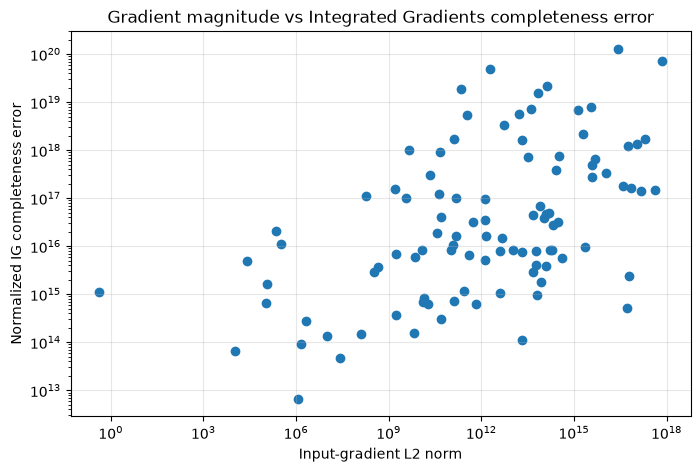

In [35]:
plt.figure(
    figsize=(8, 5)
)


plt.scatter(

    analysis_df[
        "gradient_l2"
    ],

    analysis_df[
        "normalized_completeness_error"
    ]
)


plt.xscale("log")
plt.yscale("log")


plt.xlabel(
    "Input-gradient L2 norm"
)


plt.ylabel(
    "Normalized IG completeness error"
)


plt.title(
    "Gradient magnitude vs Integrated Gradients completeness error"
)


plt.grid(
    True,
    alpha=0.3
)


plt.show()

(100, 120)


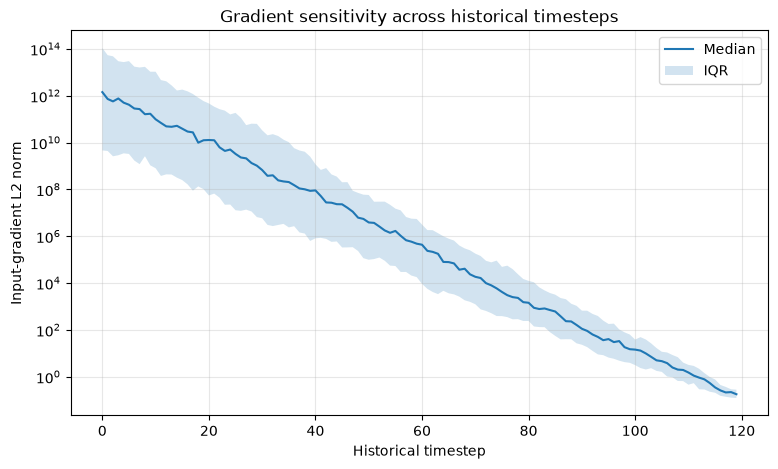

In [37]:
gradient_timestep_matrix = np.stack(
    gradient_timestep_records,
    axis=0
)


print(
    gradient_timestep_matrix.shape
)
median_gradient_by_timestep = (
    np.nanmedian(
        gradient_timestep_matrix,
        axis=0
    )
)


p25_gradient_by_timestep = (
    np.nanpercentile(
        gradient_timestep_matrix,
        25,
        axis=0
    )
)


p75_gradient_by_timestep = (
    np.nanpercentile(
        gradient_timestep_matrix,
        75,
        axis=0
    )
)
plt.figure(
    figsize=(9, 5)
)


timesteps = np.arange(
    LOOK_BACK
)


plt.plot(
    timesteps,
    median_gradient_by_timestep,
    label="Median"
)


plt.fill_between(
    timesteps,
    p25_gradient_by_timestep,
    p75_gradient_by_timestep,
    alpha=0.2,
    label="IQR"
)


plt.yscale("log")


plt.xlabel(
    "Historical timestep"
)


plt.ylabel(
    "Input-gradient L2 norm"
)


plt.title(
    "Gradient sensitivity across historical timesteps"
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)


plt.show()


In [38]:
multi_sample_df.to_csv(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_attribution_reliability.csv",

    index=False
)


distribution_summary.to_csv(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_distribution_summary.csv"
)


completeness_threshold_df.to_csv(

    RESEARCH_OUTPUT_DIR /
    "completeness_threshold_summary.csv",

    index=False
)


np.save(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_gradient_by_timestep.npy",

    gradient_timestep_matrix
)


np.save(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_ig_attributions.npy",

    np.stack(
        ig_attribution_records,
        axis=0
    )
)


np.save(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_window_starts.npy",

    audit_window_starts
)


correlation_summary = {

    "n_samples":
        int(n_successful),

    "pearson_log_gradient_vs_log_completeness":
        float(pearson_corr),

    "spearman_gradient_vs_completeness":
        float(spearman_corr),

    "runtime_seconds":
        float(total_runtime),
}


with open(

    RESEARCH_OUTPUT_DIR /
    "multi_sample_correlation_summary.json",

    "w"

) as f:

    json.dump(
        correlation_summary,
        f,
        indent=4
    )


print(
    "Saved multi-sample reliability experiment."
)

Saved multi-sample reliability experiment.
